In [27]:
import numpy as np
import sys
import matplotlib.pyplot as plt
sys.path.append('../')
from ligand_coding_model import *
from receptor_information import *

In [48]:
# --- 1. Define General Parameters ---
Nr = 2  # Number of receptors (e.g., r0, r1, r2)

# Binning parameters
# binning parameters influence the indexing of the response.
# this is why, we define them on top
Na,Nc = 10,10
# concentration bins
c_min = 0.01
c_max = 10.0
c_edges = np.logspace(np.log10(c_min), np.log10(c_max), Nc + 1)
c_centers = np.sqrt(c_edges[:-1] * c_edges[1:])
# activity bins
a_edges = np.linspace(0, 1, Na + 1)
a_centers = 0.5*(a_edges[1:] + a_edges[:-1])
a_centers[0] = 0.
a_centers[-1] = 1.

In [49]:
L_curr = 100

Kcs_3hetero, Kos_3hetero, eps_3hetero = generate_Ks(L=L_curr, n_types=2, n_hetero_sample=0,Kc_Amp=50)

A_2 = generate_activity_matrix(eps_3hetero, Kcs_3hetero, Kos_3hetero, c_centers, a_edges)
print(A_2.shape)

(100, 2, 10)


In [57]:
#events_matrix = discrete_A.transpose(0, 2, 1).reshape(-1, Nr)
events_matrix = A_2.transpose(0,2,1).reshape(-1,2)
#print(event_matrix)
val, counts = np.unique(events_matrix, axis=0, return_counts=True)
#print(counts)
#print(val)
p_mat = np.zeros(([Na for _ in range(Nr)]),dtype=float)
for value,c in zip(val,counts):
    p_mat[tuple(value)] = c


In [58]:
p_mat / (L_curr*Nc)

array([[0.297, 0.081, 0.04 , 0.02 , 0.015, 0.009, 0.007, 0.007, 0.005,
        0.011],
       [0.   , 0.013, 0.026, 0.018, 0.01 , 0.006, 0.008, 0.006, 0.008,
        0.011],
       [0.   , 0.001, 0.002, 0.013, 0.009, 0.009, 0.008, 0.005, 0.008,
        0.013],
       [0.   , 0.   , 0.   , 0.003, 0.006, 0.009, 0.007, 0.004, 0.003,
        0.014],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.007, 0.008, 0.004, 0.006,
        0.02 ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.001, 0.004, 0.009, 0.006,
        0.011],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.005, 0.008,
        0.021],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.002, 0.005,
        0.021],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.025],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.125]])

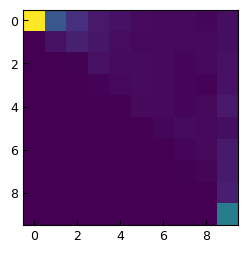

In [55]:
plt.imshow(p_mat)